# 🧹 Chapter 3 — Data Cleaning & EDA

> *"Fetching the data was Chapter 1's problem. Making it *trustworthy* is this one's."*

Two people are going to write this notebook. This first half is **our** part — it covers the cleaning
that already happens live, automatically, inside the scraper (`app/controller/bot/bots/SUT_Music_bot.py`),
plus the one real piece of feature engineering that came out of that same pipeline: the
`reaction_types` table, which turns 90+ raw emoji into a proper `(sentiment, strength)` signal.
The second half — further EDA on the fully-scraped dataset — is a 🚧 placeholder for the rest of
the team to fill in later.

**A quick note on data:** this notebook does **not** touch the real database. Everything below runs
on a small, self-contained, made-up sample built right here in the notebook — enough to demonstrate
every cleaning step faithfully, without needing DB credentials or a 14k-track dump just to read
through it. The actual functions reused below (`_get_clean_performer`, `_extract_artists`) are copied
**verbatim** from the live scraper, so the behavior — bugs included 😅 — is the real thing.


## 🗺️ What this notebook walks through

```mermaid
flowchart LR
    A["📨 Raw Telegram message\ntitle + performer strings"] --> B["🧽 Clean performer\n(strip brackets, promo junk)"]
    B --> C["✂️ Split into artists\n(ft / feat / vs / & / , / - ...)"]
    C --> D{"🏷️ Has a title?"}
    D -- no --> X["🗑️ Dropped"]
    D -- yes --> E["🪪 De-dup by (title, performer)"]
    E --> F["🎤 Tidy artists table"]
    F --> G["🎭 reaction_types\nsentiment + strength lookup"]
    G --> H["⚖️ Weighted per-track score\n(preview for Ch.4)"]
```


In [2]:
import re
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 60)
plt.rcParams["figure.facecolor"] = "white"

## 🧪 Part A.1 — A Believable Sample

This is what a batch of raw `(title, performer)` pairs looks like fresh out of Telegram, before any
cleaning happens — bracketed promo tags, stray `@handles`, inconsistent whitespace, missing titles,
and one re-shared track thrown in on purpose (`msg_id` 10231 vs 10240 are the same song, uploaded twice).


In [3]:
raw_rows = [
    {"msg_id": 10231, "title": "Blinding Lights", "performer": "The Weeknd"},
    {"msg_id": 10232, "title": "", "performer": "[Prod. by Ghost Studio] Unknown Artist @sut_music_promo"},
    {"msg_id": 10233, "title": "Bohemian Rhapsody (Live Aid 1985 Remaster)",
     "performer": "Queen ft. Freddie Mercury Tribute \u2022 download @musicbot"},
    {"msg_id": 10234, "title": "Levitating", "performer": "Dua Lipa & DaBaby"},
    {"msg_id": 10235, "title": "Shape of You   ", "performer": "  Ed Sheeran  "},
    {"msg_id": 10236, "title": None, "performer": ""},
    {"msg_id": 10237, "title": "Peaches", "performer": "Justin Bieber feat. Daniel Caesar, Giveon"},
    {"msg_id": 10238, "title": "   ", "performer": "Some Random Uploader"},
    {"msg_id": 10239, "title": "Sunflower", "performer": "Post Malone / Swae Lee"},
    {"msg_id": 10240, "title": "Blinding Lights", "performer": "The Weeknd"},  # re-share of 10231
    {"msg_id": 10241, "title": "Save Your Tears (Remix)",
     "performer": "The Weeknd ~ Ariana Grande [Official Audio] <HQ>"},
    {"msg_id": 10242, "title": "God's Plan", "performer": "Drake : ft. unknown vocalist - live version"},
]
raw_tracks = pd.DataFrame(raw_rows)
raw_tracks

,msg_id,title,performer
0,10231,Blinding Lights,The Weeknd
1,10232,,[Prod. by Ghost Studio] Unknown Artist @sut_music_promo
2,10233,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute • download @musicbot
3,10234,Levitating,Dua Lipa & DaBaby
4,10235,Shape of You,Ed Sheeran
5,10236,None,
6,10237,Peaches,"Justin Bieber feat. Daniel Caesar, Giveon"
7,10238,,Some Random Uploader
8,10239,Sunflower,Post Malone / Swae Lee
9,10240,Blinding Lights,The Weeknd


## 🧽 Part A.2 — The Actual Cleaning Functions

Copied straight out of `SUT_Music_bot.py` (`_get_clean_performer` / `_extract_artists`), not
reimplemented from memory — this is the real regex logic the scraper runs on every single message.


In [4]:
def get_clean_performer(raw_performer_str: str) -> str:
    """Verbatim port of SUT_Music_bot._get_clean_performer."""
    if not raw_performer_str:
        return ""
    # 1. Remove complete brackets first so handles/bullets inside them don't break the string
    brackets_pattern = r'(\[.*?\]|\(.*?\)|\{.*?\}|<.*?>)'
    cleaned = re.sub(brackets_pattern, '', raw_performer_str)
    # 2. Now safely remove trailing promotional junk, handles, and bullets
    cleaned = re.split(r'(?:\u2022|@)', cleaned)[0]
    return " ".join(cleaned.split()).strip()


def extract_artists(clean_performer_str: str) -> list:
    """Verbatim port of SUT_Music_bot._extract_artists."""
    if not clean_performer_str:
        return []
    delimiters_pattern = r'(?:[~:+,&\-/|\\]+|\bfeat(?:uring)?\b|\bft\b|\bvs\b)'
    possible_artists = re.split(delimiters_pattern, clean_performer_str, flags=re.IGNORECASE)
    return [a.strip() for a in possible_artists if a.strip()]


raw_tracks["clean_title"] = raw_tracks["title"].apply(
    lambda t: " ".join(str(t).split()).strip() if pd.notna(t) else ""
)
raw_tracks["clean_performer"] = raw_tracks["performer"].apply(get_clean_performer)
raw_tracks["artist_list_raw"] = raw_tracks["clean_performer"].apply(extract_artists)

raw_tracks[["title", "performer", "clean_title", "clean_performer", "artist_list_raw"]]

,title,performer,clean_title,clean_performer,artist_list_raw
0,Blinding Lights,The Weeknd,Blinding Lights,The Weeknd,[The Weeknd]
1,,[Prod. by Ghost Studio] Unknown Artist @sut_music_promo,,Unknown Artist,[Unknown Artist]
2,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute • download @musicbot,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute,"[Queen, . Freddie Mercury Tribute]"
3,Levitating,Dua Lipa & DaBaby,Levitating,Dua Lipa & DaBaby,"[Dua Lipa, DaBaby]"
4,Shape of You,Ed Sheeran,Shape of You,Ed Sheeran,[Ed Sheeran]
5,None,,,,[]
6,Peaches,"Justin Bieber feat. Daniel Caesar, Giveon",Peaches,"Justin Bieber feat. Daniel Caesar, Giveon","[Justin Bieber, . Daniel Caesar, Giveon]"
7,,Some Random Uploader,,Some Random Uploader,[Some Random Uploader]
8,Sunflower,Post Malone / Swae Lee,Sunflower,Post Malone / Swae Lee,"[Post Malone, Swae Lee]"
9,Blinding Lights,The Weeknd,Blinding Lights,The Weeknd,[The Weeknd]


In [5]:
leftover_dot = raw_tracks[raw_tracks["artist_list_raw"].apply(lambda lst: any(a.startswith(".") for a in lst))]
print(f"rows carrying the leftover-punctuation artifact: {len(leftover_dot)}")
leftover_dot[["msg_id", "clean_performer", "artist_list_raw"]]

rows carrying the leftover-punctuation artifact: 3


,msg_id,clean_performer,artist_list_raw
2,10233,Queen ft. Freddie Mercury Tribute,"[Queen, . Freddie Mercury Tribute]"
6,10237,"Justin Bieber feat. Daniel Caesar, Giveon","[Justin Bieber, . Daniel Caesar, Giveon]"
11,10242,Drake : ft. unknown vocalist - live version,"[Drake, . unknown vocalist, live version]"


In [6]:
def polish_artist_name(name: str) -> str:
    """Our own light touch-up, kept separate from the scraper's own logic on purpose."""
    return name.lstrip(".,;:- ").strip()

raw_tracks["artist_list"] = raw_tracks["artist_list_raw"].apply(
    lambda lst: [polish_artist_name(a) for a in lst]
)
raw_tracks[["clean_performer", "artist_list_raw", "artist_list"]]

,clean_performer,artist_list_raw,artist_list
0,The Weeknd,[The Weeknd],[The Weeknd]
1,Unknown Artist,[Unknown Artist],[Unknown Artist]
2,Queen ft. Freddie Mercury Tribute,"[Queen, . Freddie Mercury Tribute]","[Queen, Freddie Mercury Tribute]"
3,Dua Lipa & DaBaby,"[Dua Lipa, DaBaby]","[Dua Lipa, DaBaby]"
4,Ed Sheeran,[Ed Sheeran],[Ed Sheeran]
5,,[],[]
6,"Justin Bieber feat. Daniel Caesar, Giveon","[Justin Bieber, . Daniel Caesar, Giveon]","[Justin Bieber, Daniel Caesar, Giveon]"
7,Some Random Uploader,[Some Random Uploader],[Some Random Uploader]
8,Post Malone / Swae Lee,"[Post Malone, Swae Lee]","[Post Malone, Swae Lee]"
9,The Weeknd,[The Weeknd],[The Weeknd]


## 🗑️ Part A.3 — Dropping the No-Name Tracks

Per the scraper's own behavior: a track with no usable title (empty, missing, or whitespace-only —
rows 1, 5, and 7 in our sample) never makes it into the database at all. This is done at the source,
not cleaned up after the fact, so the DB stays clean *by construction*.


In [7]:
has_title = raw_tracks["clean_title"].str.len() > 0
dropped = raw_tracks[~has_title]
named_tracks = raw_tracks[has_title].reset_index(drop=True)

print(f"before: {len(raw_tracks)} rows  ->  after dropping no-name tracks: {len(named_tracks)}  "
      f"(dropped {len(dropped)})")
dropped[["msg_id", "title", "performer"]]

before: 12 rows  ->  after dropping no-name tracks: 9  (dropped 3)


,msg_id,title,performer
1,10232,,[Prod. by Ghost Studio] Unknown Artist @sut_music_promo
5,10236,None,
7,10238,,Some Random Uploader


## 🪪 Part A.4 — De-duplication by `(title, performer)`

If a track's already in the database, a re-share doesn't create a duplicate row — the new uploader
just gets appended to that track's `uploaded_by` list instead. Here that's `(10231, 10240)` for
*"Blinding Lights"*.


In [8]:
named_tracks["dedup_key"] = (
    named_tracks["clean_title"].str.lower() + "||" + named_tracks["clean_performer"].str.lower()
)
print(f"re-shared tracks found: {named_tracks.duplicated(subset='dedup_key', keep='first').sum()}")

uploaded_by = named_tracks.groupby("dedup_key")["msg_id"].apply(list)
tracks_clean = named_tracks.drop_duplicates(subset="dedup_key", keep="first").copy()
tracks_clean["uploaded_by_msg_ids"] = tracks_clean["dedup_key"].map(uploaded_by)

tracks_clean[["clean_title", "clean_performer", "uploaded_by_msg_ids"]]

re-shared tracks found: 1


,clean_title,clean_performer,uploaded_by_msg_ids
0,Blinding Lights,The Weeknd,"[10231, 10240]"
1,Bohemian Rhapsody (Live Aid 1985 Remaster),Queen ft. Freddie Mercury Tribute,[10233]
2,Levitating,Dua Lipa & DaBaby,[10234]
3,Shape of You,Ed Sheeran,[10235]
4,Peaches,"Justin Bieber feat. Daniel Caesar, Giveon",[10237]
5,Sunflower,Post Malone / Swae Lee,[10239]
7,Save Your Tears (Remix),The Weeknd ~ Ariana Grande,[10241]
8,God's Plan,Drake : ft. unknown vocalist - live version,[10242]


## 🎤 Part A.5 — A Tidy Artists Table

One row per `(track, artist)` pair — the shape everything downstream (artist pages, per-artist
reaction rollups, the recommendation engine) actually wants to consume.


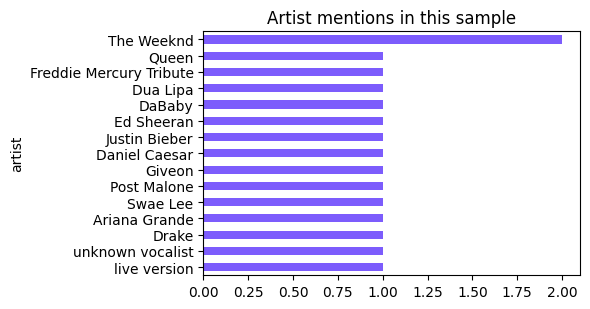

In [9]:
artists_tidy = tracks_clean.explode("artist_list").rename(columns={"artist_list": "artist"})
artists_tidy = artists_tidy[artists_tidy["artist"].str.len() > 0]

fig, ax = plt.subplots(figsize=(6, 3.2))
artists_tidy["artist"].value_counts().plot(kind="barh", ax=ax, color="#7C5CFC")
ax.set_title("Artist mentions in this sample")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Notice `"unknown vocalist"` and `"live version"` sitting in there as if they were real artists —
straight from the `"Drake : ft. unknown vocalist - live version"` string. A good reminder that
regex-based artist splitting is a *heuristic*, not ground truth, and the tail end of this
distribution is worth a periodic manual glance.


## 🎭 Part A.6 — Feature Engineering: the `reaction_types` Table

This is the one real piece of feature engineering to come out of the scraping stage. Every reaction
Telegram lets people leave is *just an emoji* — 🔥, 😢, 💀, whatever people feel like clicking. On its
own, an emoji is not a feature. So each one was hand-tagged with:

- **`sentiment`** — `like` / `neutral` / `dislike`, the coarse bucket
- **`strength`** — a signed float roughly on a `-5 … +5` scale, how *much* of that sentiment it carries
- **`description`** — a short human gloss on what the emoji is actually meant to convey

That turns something as flat as "this track got 40 reactions" into a real, weighted signal: 40
reactions that are mostly 👍 (solid, +3) reads very differently from 40 that are mostly 🤯 (insane
production, +5) or 😡 (irritating, -4). This table is what makes that distinction possible, and it's
the direct ancestor of the scoring used later in the recommendation engine (Chapter 4).

This is the **real, production `reaction_types` table** — not a sample.


In [10]:
reaction_types_csv = """id,emoji,sentiment,strength,description
1,\u2764\ufe0f,like,4,Love / Deep Affection
2,\U0001F525,like,4.5,Fire / Viral Hit
3,\U0001F4AF,like,4,Perfect / Masterpiece
4,\u2764\ufe0f\u200d\U0001F525,like,5,Passionate / Intense
5,\U0001F680,like,3.5,Energizing / Banger
6,\U0001F451,like,3.5,Goat Track
7,\U0001F3C6,like,3,Award Worthy
8,\U0001F970,like,4,Heart-warming
9,\U0001F929,like,4.5,Star-Struck / Amazing Production
10,\U0001F389,like,4,Party / Dance Vibe
11,\U0001F496,like,4.5,Sparkling / High Production
12,\U0001F49E,like,4.5,Resonating Hearts
13,\U0001F493,like,4.5,High Energy / Heart-pounding
14,\U0001F497,like,4.5,Growing Emotional Connection
15,\U0001F49D,like,4.5,Gifted Melody
16,\u26A1,like,2,Electrifying
17,\U0001F44D,like,3,Solid Track / Approval
18,\U0001F44F,like,1,Well Produced / Applause
19,\U0001F9E0,like,1,Deep / Genius Lyrics
20,\U0001F91D,like,3,Relatable Vibe
21,\U0001F37E,like,5,Celebration Pop
22,\U0001F48B,like,5,Seductive / Smooth Vibe
23,\U0001F984,like,3,Unique / Magical Sound
24,\U0001F54A\ufe0f,like,4.5,Peaceful / Chill Vibe
25,\U0001F49F,like,4.5,Pleasant / Soft Vibe
26,\U0001F4B5,like,3.5,Rich Production Value
27,\U0001F47E,like,2,Synthwave / Gaming Vibe
28,\U0001F388,neutral,1,Lighthearted / Feel-good
29,\U0001F34C,dislike,-4,Fun / Quirky Track
30,\U0001F349,neutral,0,Summer / Refreshing Vibe
31,\U0001F353,like,3,Sweet / Acoustic Vibe
32,\U0001F192,like,3.5,Trendy / Cool Track
33,\U0001F43E,neutral,1,Cute / Playful Beats
34,\U0001F485,like,3.5,Sassy / Confident Anthems
35,\U0001F62D,like,4.5,Deeply Moving / Beautifully Sad
36,\U0001F631,like,4,Mind-blowing Drop / Shocking Twist
37,\U0001F622,like,4,Melancholic / Nostalgic Melodies
38,\U0001F494,like,3.5,Heartbreak Anthem / Deep Lyrics
39,\U0001F914,neutral,-1,Experimental / Complex Music
40,\U0001F9D0,neutral,-1.5,Analytical Listening / Complex Production
41,\U0001F610,neutral,-1,Unremarkable / Plain Track
42,\U0001F937,dislike,-2,Indifferent / Not My Genre
43,\U0001F62E,neutral,2,Surprising Element
44,\U0001F4AC,neutral,0,Talk-heavy / Podcast Vibe
45,\U0001F440,dislike,-2,Intriguing / Hidden Gem
46,Ghost,neutral,1,Eerie / Ambient Sounds
47,\U0001F47B,like,2.5,Spooky / Electro-Goth Beat
48,\U0001F468\u200d\U0001F4BB,neutral,1.5,Lo-Fi / Focus / Coding Music
49,\U0001F431,like,2.5,Whimsical / Cozy Track
50,Dogs,like,2.5,Upbeat / Background Noise
51,\U0001F436,neutral,1,Friendly / Casual Listening
52,\U0001F430,neutral,1,Bouncy / Fast-paced
53,\U0001F98A,neutral,1.5,Clever Remix / Slick Beats
54,\u2603\ufe0f,like,3.5,Winter / Seasonal Vibe
55,\U0001F384,like,3.5,Holiday / Festive Theme
56,\u2764,like,4,Standard Like
57,\u2764\u200d\U0001F525,like,5,Warm Interest
58,\U0001F923,like,2,Funny / Satirical Lyrics
59,\U0001F498,like,3.5,Catchy Love Song
60,\U0001F54A,like,4,Calm / Ambient Outro
61,\U0001F44C,like,3.5,Decent / Acceptable Mix
62,\U0001F92F,like,5,Insane Production / Complex Drop
63,\U0001F48A,neutral,2,Trippy / Psychedelic Sound
64,\U0001F937\u200d\u2642,neutral,-1.5,Undecided Response
65,\U0001F385,like,2.5,Christmas / Nostalgic Track
66,\U0001F31A,dislike,-3,Dark / Underground Vibe
67,\U0001FAE1,neutral,2,Respect to a Classic Track
68,\U0001F64F,like,2.5,Soulful / Spiritual Melodies
69,\U0001F60D,like,2.5,Highly Captivating Hook
70,\U0001F433,neutral,-2,Deep / Low-Frequency Bass
71,\U0001F971,dislike,-4,Boring / Derivative Track
72,\U0001F634,dislike,-3.5,Tiring / Low-energy Skater
73,\U0001F644,dislike,-3,Annoying / Cliche Lyrics
74,\U0001F928,dislike,-3,Off-key / Poorly Mixed
75,\U0001F624,dislike,-4.5,Aggravating / Bad Noise
76,\U0001F621,dislike,-4,Irritating Sonic Choices
77,\U0001F92C,dislike,-5,Unlistenable Noise
78,\U0001F47F,like,4,Harsh / Malicious Frequency
79,\U0001F44E,dislike,-4,Bad Track / Thumbs Down
80,\U0001F6AB,neutral,-0.5,Skip Immediately / Do Not Recommend
81,\U0001F649,dislike,-4.5,Terrible Audio / Ear Hurting
82,\U0001F648,neutral,0.5,Bad Performance / Can't Watch
83,\U0001F64A,dislike,-4,Awful Vocals
84,\U0001F974,dislike,-5,Disorienting / Awful Mix
85,\U0001F922,dislike,-5,Repulsive Production
86,\U0001F92E,dislike,-5,Hated Everything About It
87,\U0001F4A9,dislike,-5,Garbage Quality / Worst Track
88,\U0001F921,dislike,-5,Joke Track / Fake Artist
89,\U0001F595,dislike,-5,Offensive / Total Rejection
90,\U0001F601,like,2.5,
91,\U0001F917,like,4,
92,\u270D,like,2.5,
93,\U0001F5FF,neutral,1,
94,\U0001F32D,dislike,-2,
95,CustomEmoji,neutral,0,
96,\U0001F60E,like,3,
97,\U0001F913,like,2,
98,\u2603,like,3.5,Winter / Seasonal Vibe
"""

reaction_types = (
    pd.read_csv(io.StringIO(reaction_types_csv), keep_default_na=False)
    .sort_values("id")
    .reset_index(drop=True)
)
print(reaction_types.shape)
reaction_types.head(10)

(98, 5)


,id,emoji,sentiment,strength,description
0,1,❤️,like,4.0,Love / Deep Affection
1,2,🔥,like,4.5,Fire / Viral Hit
2,3,💯,like,4.0,Perfect / Masterpiece
3,4,❤️‍🔥,like,5.0,Passionate / Intense
4,5,🚀,like,3.5,Energizing / Banger
5,6,👑,like,3.5,Goat Track
6,7,🏆,like,3.0,Award Worthy
7,8,🥰,like,4.0,Heart-warming
8,9,🤩,like,4.5,Star-Struck / Amazing Production
9,10,🎉,like,4.0,Party / Dance Vibe


### 📊 Sentiment distribution


sentiment
like       56
neutral    21
dislike    21
Name: count, dtype: int64


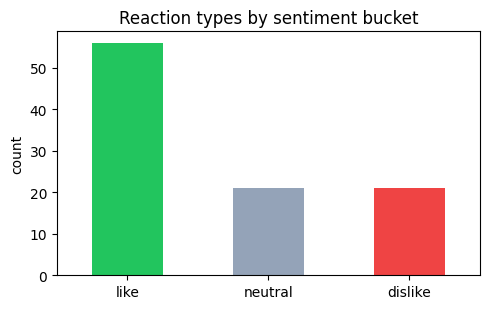

In [11]:
sentiment_counts = reaction_types["sentiment"].value_counts()
print(sentiment_counts)

fig, ax = plt.subplots(figsize=(5, 3.2))
sentiment_counts.reindex(["like", "neutral", "dislike"]).plot(
    kind="bar", ax=ax, color=["#22C55E", "#94A3B8", "#EF4444"]
)
ax.set_title("Reaction types by sentiment bucket")
ax.set_xlabel("")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### ⚖️ Strength distribution per sentiment

`like` reactions cluster around +3.5, `dislike` around -4 — both fairly tight. `neutral` is the
noisiest bucket by far (it ranges from -2 all the way to +2), which tracks with what "neutral" should
mean: not *no* signal, just no consistent *direction* to it.


           count  mean   std  min   25%  50%  75%  max
sentiment                                             
dislike     21.0 -3.93  1.06 -5.0 -5.00 -4.0 -3.0 -2.0
like        56.0  3.51  1.00  1.0  2.88  3.5  4.5  5.0
neutral     21.0  0.38  1.23 -2.0 -0.50  1.0  1.0  2.0


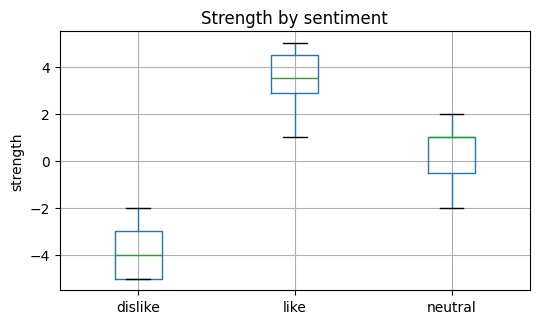

In [12]:
print(reaction_types.groupby("sentiment")["strength"].describe().round(2))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
reaction_types.boxplot(column="strength", by="sentiment", ax=ax)
ax.set_title("Strength by sentiment")
plt.suptitle("")
ax.set_xlabel("")
ax.set_ylabel("strength")
plt.tight_layout()
plt.show()

### 🔍 A Data-Quality Pass Over `reaction_types`

Three things worth flagging to whoever maintains this table next:


In [13]:
# 1) Emoji that only differ by an invisible Unicode variation-selector / ZWJ character
#    render identically but got registered as two separate rows.
def norm_emoji(e: str) -> str:
    return str(e).replace("\ufe0f", "").replace("\u200d", "")

reaction_types["emoji_norm"] = reaction_types["emoji"].apply(norm_emoji)
visual_dupes = reaction_types.groupby("emoji_norm").filter(lambda g: len(g) > 1).sort_values("emoji_norm")
visual_dupes[["id", "emoji", "sentiment", "strength"]]

,id,emoji,sentiment,strength
53,54,☃️,like,3.5
97,98,☃,like,3.5
0,1,❤️,like,4.0
55,56,❤,like,4.0
3,4,❤️‍🔥,like,5.0
56,57,❤‍🔥,like,5.0
23,24,🕊️,like,4.5
59,60,🕊,like,4.0


❤️/❤, ❤️‍🔥/❤‍🔥, and ☃️/☃ are exact visual duplicates and happen to agree on strength — harmless,
just redundant rows. **🕊️/🕊 (id 24 vs id 60) is the one that actually matters:** same emoji, but
**4.5 vs 4.0** strength, and two different descriptions ("Peaceful / Chill Vibe" vs "Calm / Ambient
Outro"). That's a real inconsistency, not just a redundant row, and worth reconciling before this
table feeds the recommendation engine.


In [14]:
# 2) A few rows store an English word instead of an actual emoji glyph (ids 46, 50, 95) --
#    most likely custom Telegram emoji/stickers that got stored as a text placeholder
#    rather than a resolvable glyph.
def looks_like_placeholder(e: str) -> bool:
    e = str(e)
    return e.isascii() and e.isalpha()

placeholder_rows = reaction_types[reaction_types["emoji"].apply(looks_like_placeholder)]
placeholder_rows[["id", "emoji", "sentiment", "description"]]

,id,emoji,sentiment,description
45,46,Ghost,neutral,Eerie / Ambient Sounds
49,50,Dogs,like,Upbeat / Background Noise
94,95,CustomEmoji,neutral,


In [15]:
# 3) Rows with no description at all -- fine for the model (sentiment + strength still work),
#    but worth a follow-up pass for anything human-facing.
missing_desc = reaction_types[reaction_types["description"].astype(str).str.strip() == ""]
print(f"reaction types missing a description: {len(missing_desc)} / {len(reaction_types)}")
missing_desc[["id", "emoji", "sentiment", "strength"]]

reaction types missing a description: 8 / 98


,id,emoji,sentiment,strength
89,90,😁,like,2.5
90,91,🤗,like,4.0
91,92,✍,like,2.5
92,93,🗿,neutral,1.0
93,94,🌭,dislike,-2.0
94,95,CustomEmoji,neutral,0.0
95,96,😎,like,3.0
96,97,🤓,like,2.0


### 🏆 Extremes — the nicest & harshest reactions on the books


In [16]:
display_cols = ["emoji", "strength", "description"]

print("Top 5 strongest 👍 reactions:")
top_like = reaction_types[reaction_types["sentiment"] == "like"].nlargest(5, "strength")
print(top_like[display_cols].to_string(index=False))

print("\nTop 5 harshest 👎 reactions:")
harsh_dislike = reaction_types[reaction_types["sentiment"] == "dislike"].nsmallest(5, "strength")
print(harsh_dislike[display_cols].to_string(index=False))

Top 5 strongest 👍 reactions:
emoji  strength                      description
 ❤️‍🔥       5.0             Passionate / Intense
    🍾       5.0                  Celebration Pop
    💋       5.0          Seductive / Smooth Vibe
  ❤‍🔥       5.0                    Warm Interest
    🤯       5.0 Insane Production / Complex Drop

Top 5 harshest 👎 reactions:
emoji  strength                   description
    🤬      -5.0            Unlistenable Noise
    🥴      -5.0      Disorienting / Awful Mix
    🤢      -5.0          Repulsive Production
    🤮      -5.0     Hated Everything About It
    💩      -5.0 Garbage Quality / Worst Track


## 🔗 Part A.7 — Putting It Together: a Tiny Weighted-Score Demo

A quick, self-contained preview of *why* this table exists: joining a handful of made-up reactions
against `reaction_types` and reducing each track down to one weighted number. This exact idea —
scaled up to the real reaction volume — is what feeds the recommendation engine in Chapter 4.


In [17]:
sample_reactions = pd.DataFrame([
    {"track": "Blinding Lights", "reaction_id": 1},   # \u2764\ufe0f like +4
    {"track": "Blinding Lights", "reaction_id": 2},   # \U0001F525 like +4.5
    {"track": "Blinding Lights", "reaction_id": 17},  # \U0001F44D like +3
    {"track": "God's Plan",      "reaction_id": 29},  # \U0001F34C dislike -4
    {"track": "God's Plan",      "reaction_id": 76},  # \U0001F621 dislike -4
    {"track": "God's Plan",      "reaction_id": 1},   # \u2764\ufe0f like +4  (mixed reception)
    {"track": "Levitating",      "reaction_id": 41},  # \U0001F610 neutral -1
    {"track": "Levitating",      "reaction_id": 44},  # \U0001F4AC neutral 0
])

scored = sample_reactions.merge(
    reaction_types[["id", "strength", "sentiment"]], left_on="reaction_id", right_on="id"
)
track_scores = (
    scored.groupby("track")["strength"]
    .agg(avg_strength="mean", reaction_count="count")
    .sort_values("avg_strength", ascending=False)
)
track_scores

,avg_strength,reaction_count
track,,
Blinding Lights,3.833333,3
Levitating,-0.500000,2
God's Plan,-1.333333,3


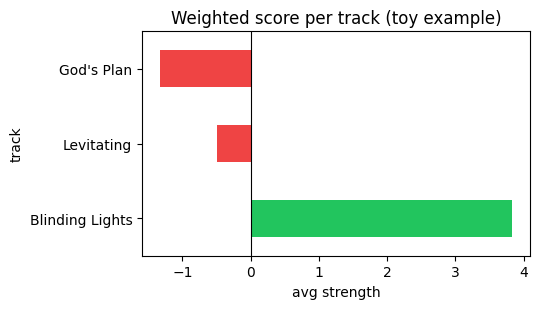

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 3.2))
colors = ["#22C55E" if v >= 0 else "#EF4444" for v in track_scores["avg_strength"]]
track_scores["avg_strength"].plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Weighted score per track (toy example)")
ax.set_xlabel("avg strength")
plt.tight_layout()
plt.show()

## ✅ Part A Recap

- Reused the scraper's real `_get_clean_performer` / `_extract_artists` logic and confirmed how it
  behaves on messy input, warts included (the leftover `"."` after `ft.`/`feat.`).
- Replicated the no-title drop and the `(title, performer)` de-dup / `uploaded_by` merge behavior.
- Loaded the real, production `reaction_types` table and ran a proper data-quality pass over it:
  sentiment/strength distributions, visual-duplicate emoji, placeholder text rows, and missing
  descriptions.
- Closed with a tiny weighted-scoring demo tying the two halves of this notebook together — a direct
  preview of the scoring approach used in Chapter 4.

---

## 🚧 Part B — To Be Continued by the Team

The rest of the EDA — run against the actual scraped dataset once it's available here — continues
below. *(Left intentionally empty; not this notebook's part to fill in.)*
